# Customer Churn Prediction & Retention Analytics

## Project Objective

The objective of this project is to analyze customer churn behavior
and develop a machine learning model that predicts whether a customer
is likely to churn.

The project includes:

- Data cleaning
- Exploratory Data Analysis
- Feature engineering
- Machine learning classification
- Model evaluation
- Model interpretation
- Customer churn risk scoring

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [5]:
df= pd.read_csv("../data/Telco-Customer-Churn.csv")

In [6]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["TotalCharges"].dtype

dtype('O')

In [14]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [15]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [16]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [17]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [18]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df["customerID"].nunique()

7043

In [20]:
df = df.drop("customerID", axis=1)

In [21]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [23]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

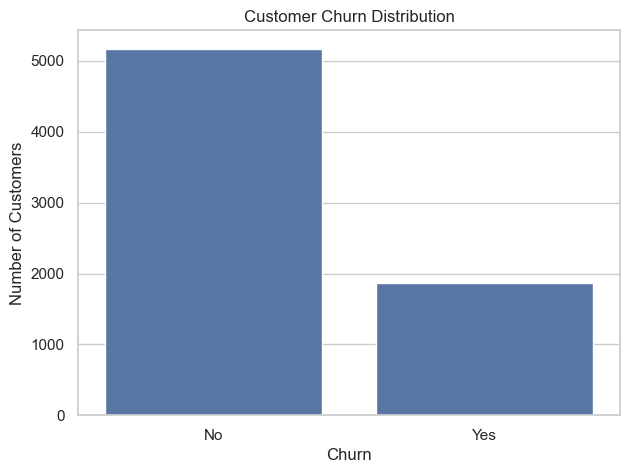

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

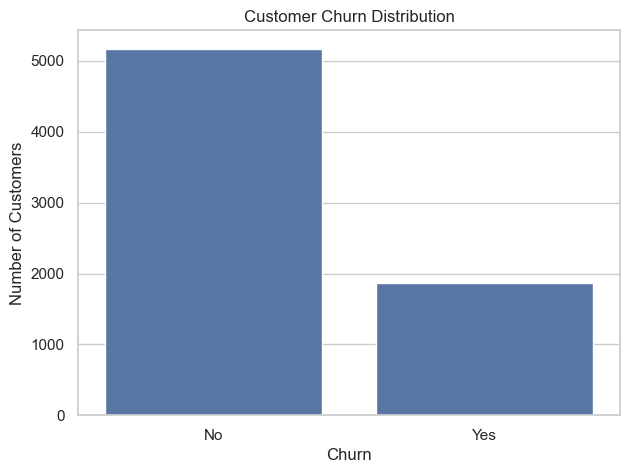

In [25]:
#for portfolio
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig(
    "../figures/churn_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [26]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


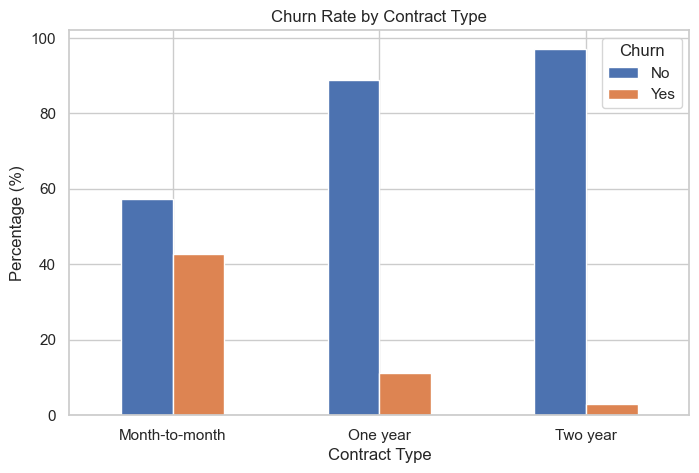

In [27]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

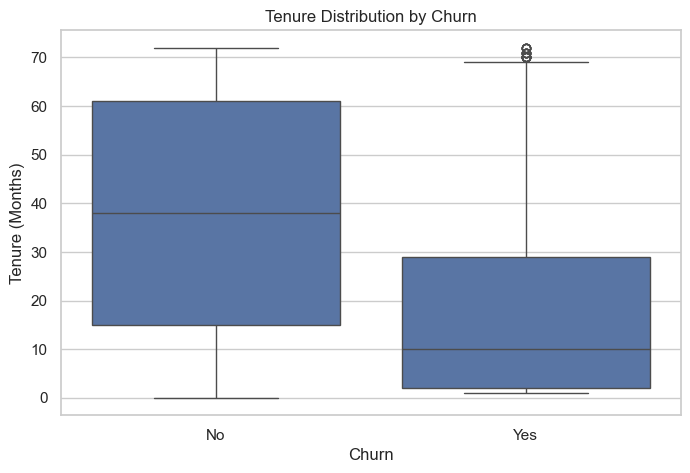

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

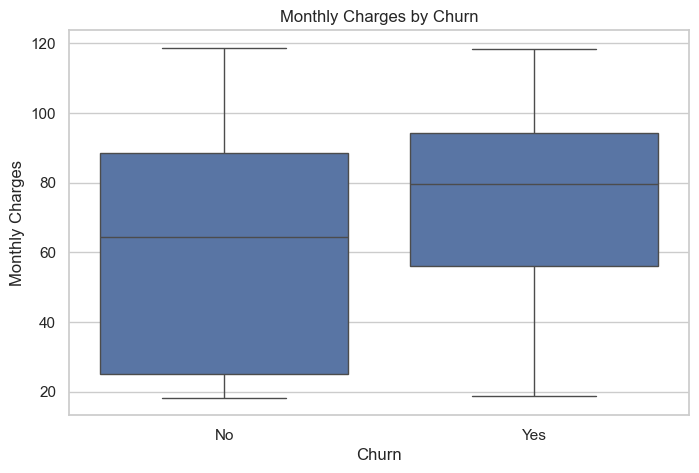

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [30]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [31]:
df.groupby("Churn")["MonthlyCharges"].median()

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

In [32]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


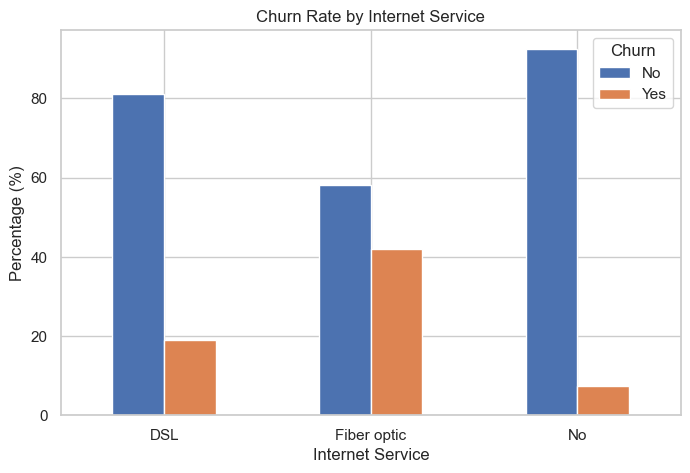

In [33]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [34]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


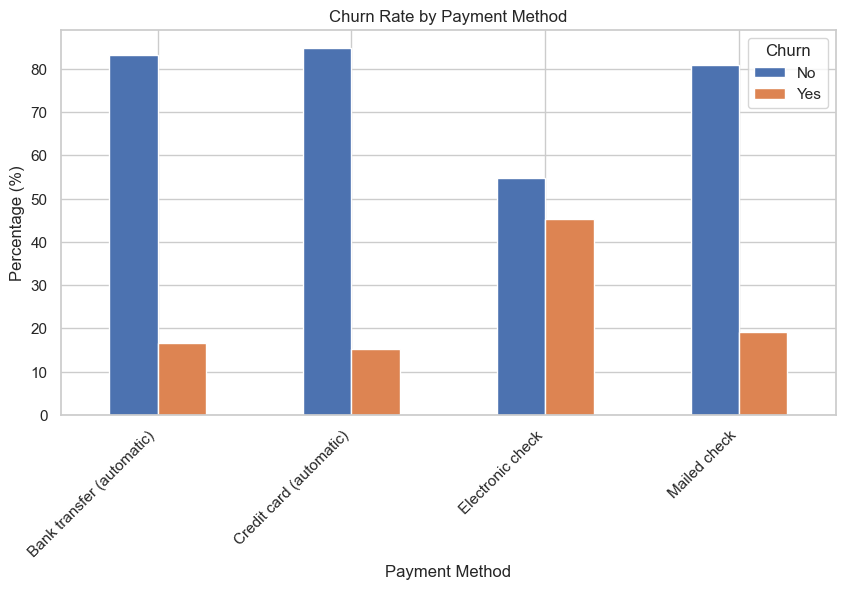

In [35]:
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Churn")

plt.show()

In [36]:
techsupport_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


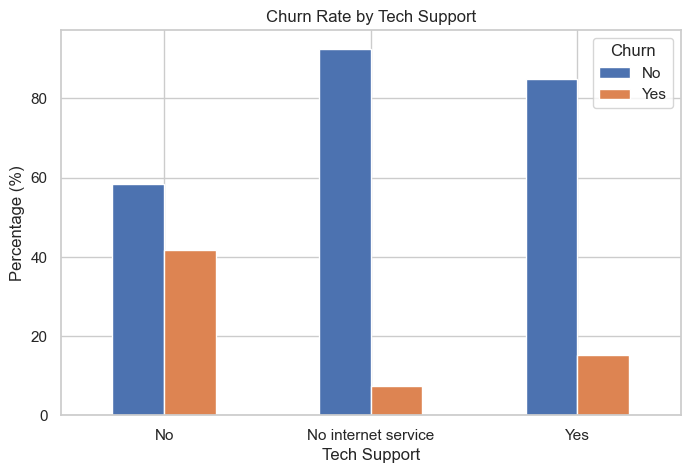

In [37]:
techsupport_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [38]:
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

In [39]:
senior_churn = pd.crosstab(
    df["SeniorCitizenLabel"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizenLabel,,
No,76.393832,23.606168
Yes,58.318739,41.681261


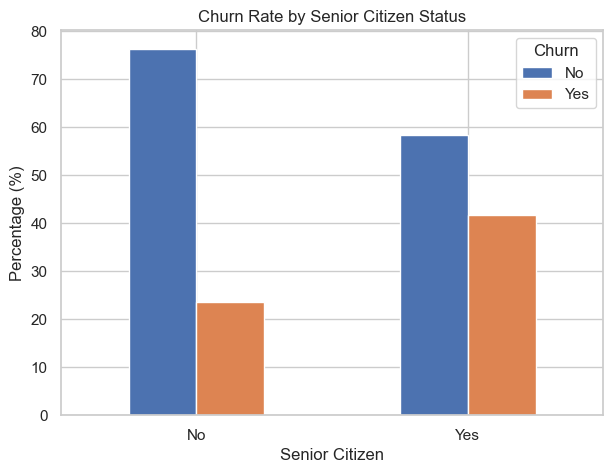

In [40]:
senior_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [41]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


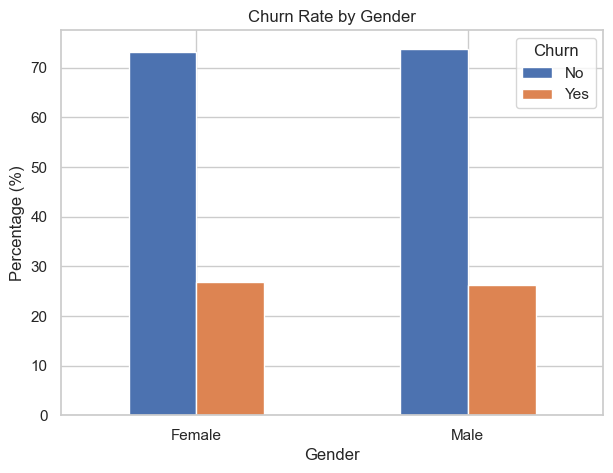

In [42]:
gender_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [43]:
df["Churn_numeric"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [44]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

In [45]:
correlation = numeric_df.corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_numeric
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.103006,0.826178,0.651174,1.000000,-0.198324
Churn_numeric,0.150889,-0.352229,0.193356,-0.198324,1.000000


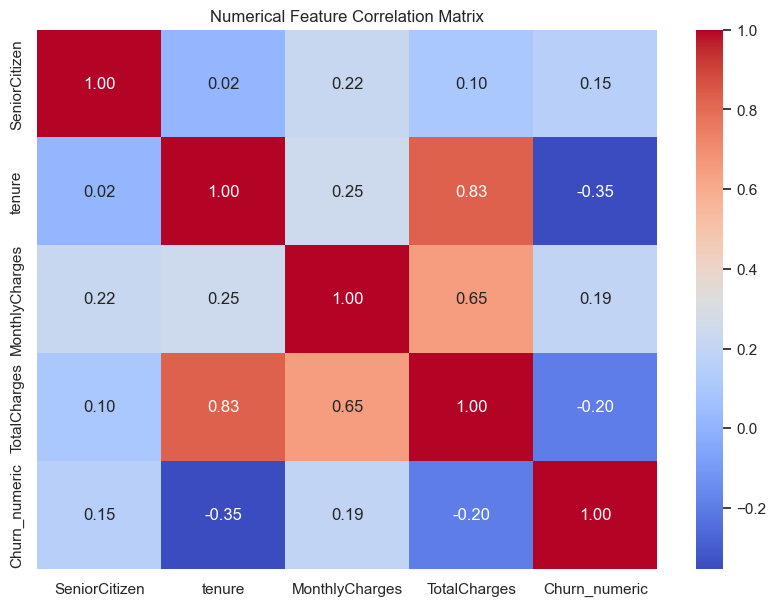

In [66]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Feature Correlation Matrix")

plt.show()

In [46]:
plt.savefig(
    "../figures/contract_vs_churn.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [47]:
df = df.drop(
    ["SeniorCitizenLabel", "Churn_numeric"],
    axis=1
)

In [48]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [50]:
df["num_services"] = (
    df[service_columns] == "Yes"
).sum(axis=1)

In [51]:
df[["num_services"] + service_columns].head(10)

,num_services,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,1,No,Yes,No,No,No,No
1,2,Yes,No,Yes,No,No,No
2,2,Yes,Yes,No,No,No,No
3,3,Yes,No,Yes,Yes,No,No
4,0,No,No,No,No,No,No
5,3,No,No,Yes,No,Yes,Yes
6,2,No,Yes,No,No,Yes,No
7,1,Yes,No,No,No,No,No
8,4,No,No,Yes,Yes,Yes,Yes
9,2,Yes,Yes,No,No,No,No


In [52]:
df["num_services"].value_counts().sort_index()

num_services
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

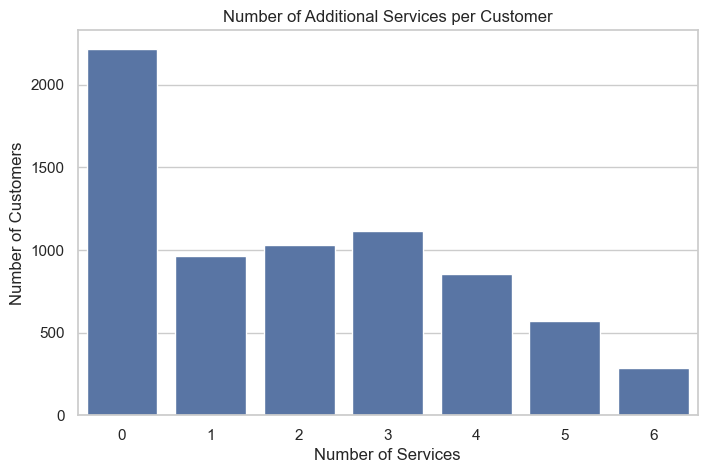

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="num_services"
)

plt.title("Number of Additional Services per Customer")
plt.xlabel("Number of Services")
plt.ylabel("Number of Customers")

plt.show()

In [54]:
df["is_long_term"] = np.where(
    df["tenure"] >= 24,
    1,
    0
)

In [55]:
df["is_long_term"].value_counts()

is_long_term
1    3927
0    3116
Name: count, dtype: int64

In [56]:
df.shape

(7043, 22)

In [57]:
df.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'num_services',
 'is_long_term']

In [58]:
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [59]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [60]:
X = df.drop(
    "Churn",
    axis=1
)

In [81]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,num_services,is_long_term
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,1,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,2,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,2,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,3,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0


In [61]:
X.shape

(7043, 21)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [63]:
X_train.shape

(5634, 21)

In [64]:
X_test.shape

(1409, 21)

In [65]:
y_train.value_counts(normalize=True)

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [66]:
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [67]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numeric_features

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'num_services',
 'is_long_term']

In [68]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [69]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [70]:


from sklearn.dummy import DummyClassifier

In [71]:
dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

In [72]:
dummy_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
dummy_pred = dummy_model.predict(X_test)

In [74]:
accuracy_score(
    y_test,
    dummy_pred
)

0.7345635202271115

In [75]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [76]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [77]:
y_pred_lr = logistic_pipeline.predict(
    X_test
)

In [78]:
y_prob_lr = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

In [79]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_roc_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

In [80]:
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_roc_auc)

Accuracy : 0.8069552874378992
Precision: 0.659375
Recall   : 0.5641711229946524
F1 Score : 0.6080691642651297
ROC-AUC  : 0.841830065359477


In [81]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



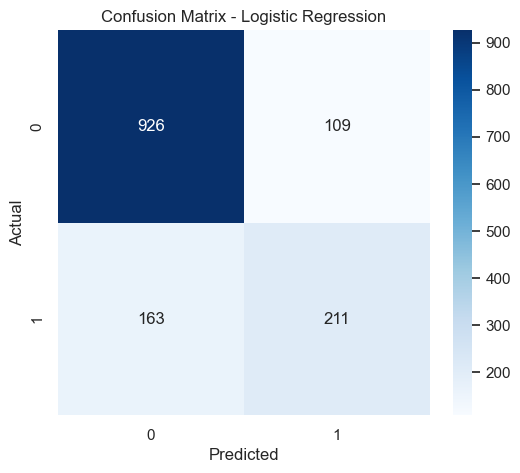

In [82]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [83]:
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [84]:
decision_tree_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [85]:
y_pred_dt = decision_tree_pipeline.predict(
    X_test
)

In [86]:
y_prob_dt = decision_tree_pipeline.predict_proba(
    X_test
)[:, 1]

In [87]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

dt_roc_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

In [88]:
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_roc_auc)

Accuracy : 0.723207948899929
Precision: 0.4796954314720812
Recall   : 0.5053475935828877
F1 Score : 0.4921875
ROC-AUC  : 0.6534010178511458


In [89]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

In [90]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [91]:
y_pred_rf = random_forest_pipeline.predict(
    X_test
)

In [92]:
y_prob_rf = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

In [93]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

In [94]:
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Accuracy : 0.7799858055358411
Precision: 0.6095890410958904
Recall   : 0.47593582887700536
F1 Score : 0.5345345345345346
ROC-AUC  : 0.8207186959105117


In [95]:
model_results = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, dummy_pred),
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    
    "Precision": [
        precision_score(y_test, dummy_pred),
        lr_precision,
        dt_precision,
        rf_precision
    ],
    
    "Recall": [
        recall_score(y_test, dummy_pred),
        lr_recall,
        dt_recall,
        rf_recall
    ],
    
    "F1": [
        f1_score(y_test, dummy_pred),
        lr_f1,
        dt_f1,
        rf_f1
    ],
    
    "ROC-AUC": [
        np.nan,
        lr_roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy Baseline,0.734564,0.000000,0.000000,0.000000,NaN
1,Logistic Regression,0.806955,0.659375,0.564171,0.608069,0.841830
2,Decision Tree,0.723208,0.479695,0.505348,0.492188,0.653401
3,Random Forest,0.779986,0.609589,0.475936,0.534535,0.820719


In [96]:
model_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Logistic Regression,0.806955,0.659375,0.564171,0.608069,0.841830
3,Random Forest,0.779986,0.609589,0.475936,0.534535,0.820719
2,Decision Tree,0.723208,0.479695,0.505348,0.492188,0.653401
0,Dummy Baseline,0.734564,0.000000,0.000000,0.000000,NaN


In [97]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_prob_dt
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

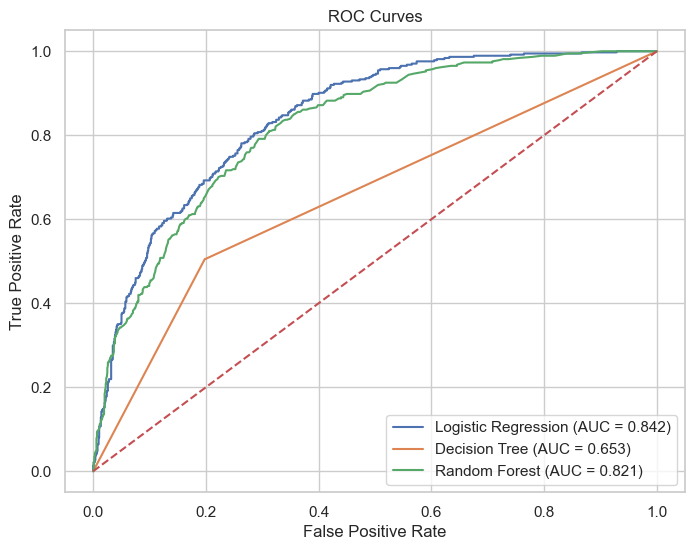

In [121]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {dt_roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [98]:
plt.savefig(
    "../figures/roc_curve.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [99]:
cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

In [100]:
print("CV Scores:", cv_scores)

print(
    "Mean ROC-AUC:",
    cv_scores.mean()
)

print(
    "Std ROC-AUC:",
    cv_scores.std()
)

CV Scores: [0.86355888 0.85337599 0.85034253 0.83610021 0.8242853 ]
Mean ROC-AUC: 0.8455325814760354
Std ROC-AUC: 0.013784184332047818


In [101]:
rf_cv_scores = cross_val_score(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

In [102]:
print("Random Forest CV Scores:", rf_cv_scores)

print(
    "Mean ROC-AUC:",
    rf_cv_scores.mean()
)

print(
    "Std ROC-AUC:",
    rf_cv_scores.std()
)

Random Forest CV Scores: [0.84092102 0.8316106  0.82118737 0.81287666 0.80878422]
Mean ROC-AUC: 0.8230759750547376
Std ROC-AUC: 0.011858607578585582


In [103]:
param_grid = {
    "model__n_estimators": [
        100,
        200,
        300
    ],
    
    "model__max_depth": [
        None,
        5,
        10,
        15
    ],
    
    "model__min_samples_split": [
        2,
        5,
        10
    ]
}

In [104]:
grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [106]:
grid_search.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 5, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [107]:
grid_search.best_params_

{'model__max_depth': 5,
 'model__min_samples_split': 10,
 'model__n_estimators': 300}

In [108]:
grid_search.best_score_

np.float64(0.844955885074587)

In [109]:
best_model = grid_search.best_estimator_

In [110]:
final_pred = best_model.predict(
    X_test
)

In [111]:
final_prob = best_model.predict_proba(
    X_test
)[:, 1]

In [112]:
final_accuracy = accuracy_score(
    y_test,
    final_pred
)

final_precision = precision_score(
    y_test,
    final_pred
)

final_recall = recall_score(
    y_test,
    final_pred
)

final_f1 = f1_score(
    y_test,
    final_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    final_prob
)

In [113]:
print("Final Model Performance")
print("-----------------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_roc_auc)

Final Model Performance
-----------------------
Accuracy : 0.7906316536550745
Precision: 0.6639004149377593
Recall   : 0.42780748663101603
F1 Score : 0.5203252032520326
ROC-AUC  : 0.8395696091348266


In [114]:
print(
    classification_report(
        y_test,
        final_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1035
           1       0.66      0.43      0.52       374

    accuracy                           0.79      1409
   macro avg       0.74      0.67      0.69      1409
weighted avg       0.78      0.79      0.77      1409



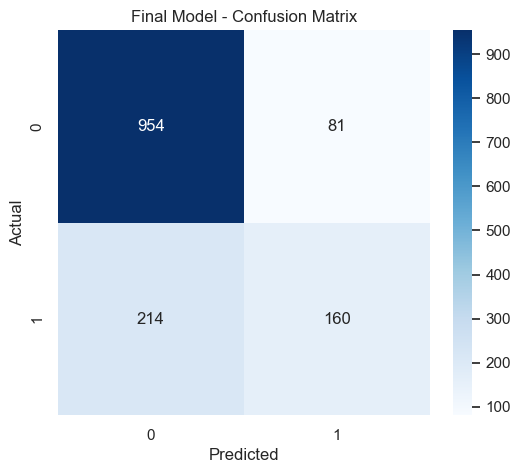

In [115]:
final_cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Model - Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [116]:
plt.savefig(
    "../figures/final_confusion_matrix.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [117]:
fitted_preprocessor = (
    best_model
    .named_steps["preprocessor"]
)

In [118]:
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

In [119]:
rf_model = (
    best_model
    .named_steps["model"]
)

In [120]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

In [121]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [122]:
feature_importance.head(20)

,Feature,Importance
38,cat__Contract_Month-to-month,0.163557
1,num__tenure,0.104240
20,cat__OnlineSecurity_No,0.089219
18,cat__InternetService_Fiber optic,0.073904
3,num__TotalCharges,0.069009
5,num__is_long_term,0.065101
29,cat__TechSupport_No,0.063626
45,cat__PaymentMethod_Electronic check,0.049731
2,num__MonthlyCharges,0.046031
40,cat__Contract_Two year,0.042814


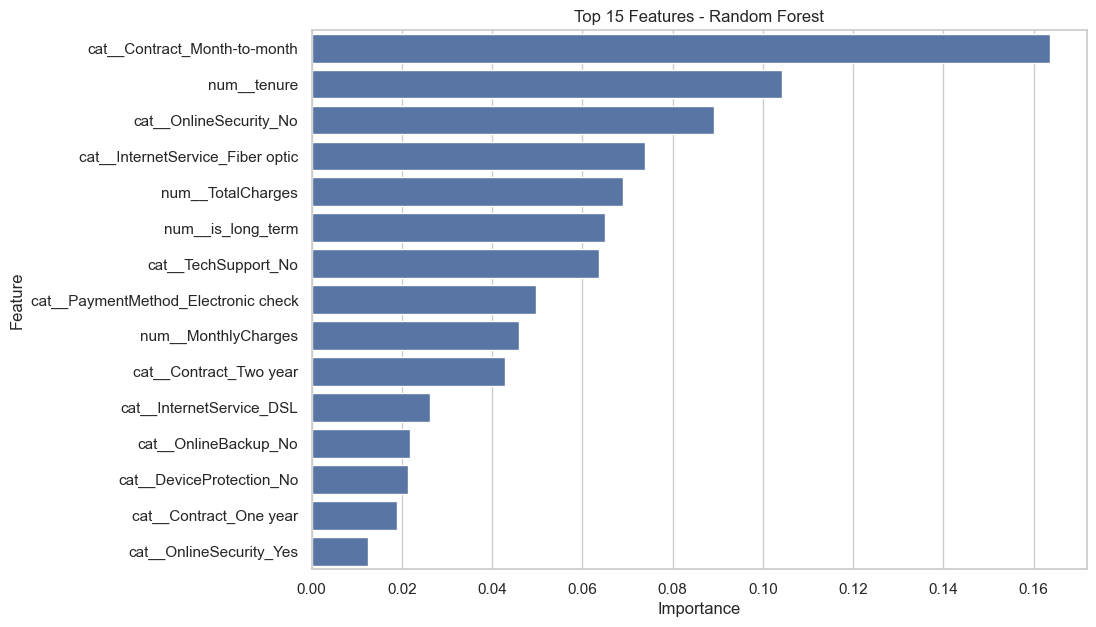

In [123]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features - Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [124]:
plt.savefig(
    "../figures/feature_importance.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [125]:
risk_df = X_test.copy()

risk_df["actual_churn"] = y_test.values

risk_df["churn_probability"] = final_prob

In [126]:
risk_df["risk_category"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"]
)

In [127]:
risk_df[
    ["churn_probability", "risk_category"]
].head(20)

,churn_probability,risk_category
437,0.064896,Low
2280,0.577216,Medium
2235,0.092618,Low
4460,0.437701,Medium
3761,0.056844,Low
5748,0.494083,Medium
3568,0.436928,Medium
2976,0.105858,Low
5928,0.013848,Low
1639,0.405438,Medium


In [128]:
high_risk_customers = risk_df[
    risk_df["risk_category"] == "High"
].copy()

high_risk_customers = high_risk_customers.sort_values(
    by="churn_probability",
    ascending=False
)

high_risk_customers.head(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,num_services,is_long_term,actual_churn,churn_probability,risk_category
4585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,1,0,1,0.732393,High
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,2,0,1,0.726687,High
6866,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,2,0,1,0.726620,High
6623,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.45,76.45,0,0,1,0.719366,High
2397,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,88.35,88.35,2,0,1,0.716544,High
2464,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,77.15,77.15,0,0,1,0.715997,High
642,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.55,89.55,2,0,1,0.714961,High
6633,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.50,74.50,0,0,1,0.714531,High
2194,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,79.50,79.50,1,0,1,0.708282,High
1731,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.60,0,0,1,0.705065,High


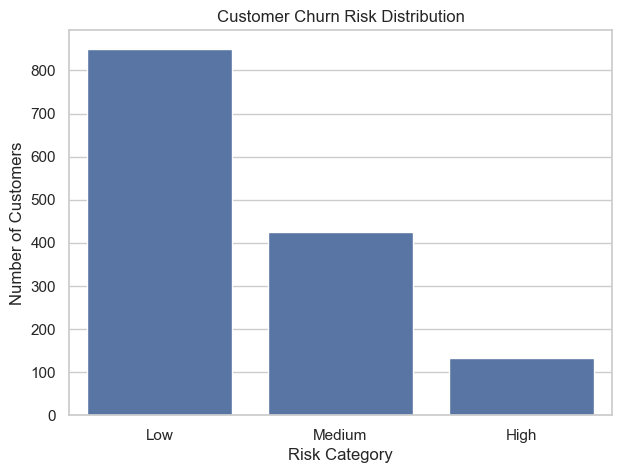

In [129]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=risk_df,
    x="risk_category",
    order=["Low", "Medium", "High"]
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.savefig(
    "../figures/risk_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [130]:
final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_summary

,Metric,Score
0,Accuracy,0.790632
1,Precision,0.663900
2,Recall,0.427807
3,F1 Score,0.520325
4,ROC-AUC,0.839570


In [131]:
import joblib

joblib.dump(
    best_model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [132]:
loaded_model = joblib.load(
    "../models/churn_model.pkl"
)

In [133]:
loaded_predictions = loaded_model.predict(X_test)

np.array_equal(
    final_pred,
    loaded_predictions
)

True